## Coupled gene families simulation

1.-	Generate the species tree
2.-	Helper to build a well-formed gene node
3.-	Apply a speciation/duplication to a lineage
4.-	The coupled simulation loop (draws + coupling rule + apply)
5.-	Run it and visualize both families
6.-	Count and print the events

Generates a random species tree with exactly 5 leaves under the Yule model (pure birth, no extinction). This is the "backbone" along which both gene families will evolve. Both families A and B live inside this same species tree.

tree_age = 1.0 is the total depth of the tree (from root to present).

birth_rate = 1.0 controls how quickly lineages split.

Species tree:
(((((8:0.21938259102416702,9:0.21938259102416702)7:0.13380353205921397,6:0.353186123083381)5:0.03462106662406961,4:0.3878071897074506)3:0.2018505860254785,2:0.5896577757329291)1:0.4103422242670709)0:0.0;


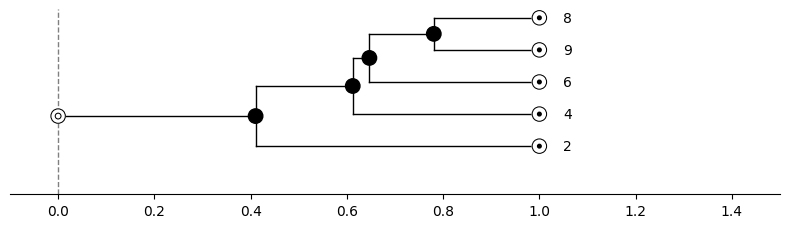

In [19]:
import random
import asymmetree.treeevolve as te
import asymmetree.visualization.tree_vis as tv
from asymmetree.utils.phylogenetic_trees import to_newick
from tralda.datastructures import Tree, TreeNode



# 1. Species tree (Yule model, max 5 leaves)

n_species = 5
tree_age = 1.0
birth_rate = 1.0

species_tree = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)
print("Species tree:")
print(to_newick(species_tree))
tv.visualize(species_tree, save_as="species_tree.pdf")

Creates a new TreeNode, which is the basic building block of a tree.

Every gene node needs three things:

1.- A label (name, e.g., A_5_1).

2.- A species attribute (which species node it lives in).

3.- A dist attribute (branch length). This is required by the visualization module — without it, tv.visualize() crashes with AttributeError: 'TreeNode' object has no attribute 'dist'.

In [20]:
# 2. Helper: create a gene node with a branch length

def make_gene_node(label, species_node, dist=None):
    node = TreeNode(label=label)
    node.species = species_node
    if dist is None:
        dist = getattr(species_node, "dist", None)
        if dist is None or dist <= 0:
            dist = random.uniform(0.05, 0.2)
    node.dist = dist
    return node

Given a lineage and an event type, it mutates the tree accordingly. Whether the event is a speciation or a duplication, the tree structure is always binary.

In [21]:
# 3. Apply an event to a family's lineage

def apply_event(lineages, idx, event, species_node, family_label):
    """
    Modify the lineage list according to the chosen event.
    - event = "speciation": split into two children on the new species node.
    - event = "duplication": split into two children on the SAME species node.
    """
    gene_node, _ = lineages[idx]
    child_dist = getattr(species_node, "dist", None)
    if child_dist is None or child_dist <= 0:
        child_dist = random.uniform(0.05, 0.2)

    if event == "speciation":
        c1 = make_gene_node(f"{family_label}_{species_node.label}_1",
                            species_node, child_dist)
        c2 = make_gene_node(f"{family_label}_{species_node.label}_2",
                            species_node, child_dist)
        gene_node.add_child(c1)
        gene_node.add_child(c2)
        gene_node.event = "S"
        lineages[idx] = (c1, species_node)
        lineages.append((c2, species_node))
    else:  # duplication
        c1 = make_gene_node(f"{family_label}_{species_node.label}_orig",
                            species_node, child_dist)
        c2 = make_gene_node(f"{family_label}_{species_node.label}_dup",
                            species_node, child_dist)
        gene_node.add_child(c1)
        gene_node.add_child(c2)
        gene_node.event = "D"
        lineages[idx] = (c1, species_node)
        lineages.append((c2, species_node))

Both families start with one ancestral gene at the root of the species tree. Each family keeps its own list of active lineages.

- preorder() visits every node root → leaves. We skip the root because nothing has happened yet.

We only take the first matching lineage (parents_A[0]). In a fully rigorous model, all lineages on that branch should be considered. This keeps the code readable and the trees small.

Each family independently rolls the dice:

- 70% chance of speciation (p_speciate = 0.7).

- 30% chance of duplication (p_duplicate = 0.3).

At this point A and B are completely decoupled.

We saved the originals (orig_A, orig_B) before any modification to avoid a feedback loop: if A forces B, we don't want B's newly-forced speciation to then force A back. Coupling is decided based on the original independent draws.

- A → B coupling: If A independently chose speciation, then with probability coupling_prob we override B's decision and force it to speciate too.

- B → A coupling: Same rule in the opposite direction. If B independently chose speciation, with probability coupling_prob A is forced to speciate.

Interpretation of coupling_prob:

- p ≈ 0 → A and B evolve independently (no coupling).

- p ≈ 1 → Whenever one family speciates, the other does too (fully synchronized).

- p ≈ 0.5 → Moderate coupling.

Coupling only fires when the trigger event is a speciation, not a duplication. If A duplicates, B is not affected. Once decisions are final (possibly forced by coupling), we actually mutate both trees by calling apply_event. If either family already has 5 leaves, it stops.

- Leaves are marked as speciations (extant genes).

- A safety loop ensures every non-root node has a dist. This prevents the visualization from crashing.

In [22]:
# 4. Coupled simulation of families A and B

def simulate_coupled_families(species_tree, coupling_prob,
                              max_leaves=5,
                              p_speciate=0.7, p_duplicate=0.3):
    """
    Simulate two gene families (A and B) that are truly coupled.

    Coupling rule (applied at every species node):
        - If A draws 'speciation' -> with prob coupling_prob, B is FORCED
          to also speciate (its own draw is overridden).
        - If B draws 'speciation' -> with prob coupling_prob, A is FORCED
          to also speciate.
        - Otherwise, each family keeps its own independent decision.

    Returns (gene_tree_A, gene_tree_B).
    """
    # ---------- initialize both families at the species root ----------
    root_A = TreeNode(label="A_root")
    root_A.dist = 0.0
    root_A.species = species_tree.root
    tree_A = Tree(root_A)

    root_B = TreeNode(label="B_root")
    root_B.dist = 0.0
    root_B.species = species_tree.root
    tree_B = Tree(root_B)

    lineages_A = [(root_A, species_tree.root)]
    lineages_B = [(root_B, species_tree.root)]

    # ---------- walk the species tree ----------
    for species_node in species_tree.preorder():
        if species_node == species_tree.root:
            continue

        # lineages sitting on the parent branch of this species node
        parents_A = [i for i, (_, sp) in enumerate(lineages_A)
                     if sp == species_node.parent]
        parents_B = [i for i, (_, sp) in enumerate(lineages_B)
                     if sp == species_node.parent]

        # ---------- independent draws ----------
        event_A = None
        event_B = None

        if parents_A:
            iA = parents_A[0]
            event_A = random.choices(
                ["speciation", "duplication"],
                weights=[p_speciate, p_duplicate]
            )[0]

        if parents_B:
            iB = parents_B[0]
            event_B = random.choices(
                ["speciation", "duplication"],
                weights=[p_speciate, p_duplicate]
            )[0]

        # ---------- coupling (based on ORIGINAL draws) ----------
        orig_A = event_A
        orig_B = event_B

        # A -> B
        if orig_A == "speciation" and random.random() < coupling_prob:
            if event_B is not None:
                event_B = "speciation"   # B is forced
                print(f"  [coupling] A speciated at {species_node.label} "
                      f"-> B FORCED to speciate")

        # B -> A
        if orig_B == "speciation" and random.random() < coupling_prob:
            if event_A is not None:
                event_A = "speciation"   # A is forced
                print(f"  [coupling] B speciated at {species_node.label} "
                      f"-> A FORCED to speciate")

        # ---------- apply the (possibly forced) events ----------
        if event_A is not None:
            apply_event(lineages_A, iA, event_A, species_node, "A")
        if event_B is not None:
            apply_event(lineages_B, iB, event_B, species_node, "B")

        # stop if either family reached the leaf budget
        if (len(list(tree_A.leaves())) >= max_leaves or
                len(list(tree_B.leaves())) >= max_leaves):
            break

    # ---------- finalize ----------
    for leaf in tree_A.leaves():
        leaf.event = "S"
    for leaf in tree_B.leaves():
        leaf.event = "S"

    for tree in (tree_A, tree_B):
        for v in tree.preorder():
            if v.parent is not None:
                if not hasattr(v, "dist") or v.dist is None:
                    v.dist = random.uniform(0.05, 0.2)

    return tree_A, tree_B


Coupling probability p = 0.538

  [coupling] A speciated at 1 -> B FORCED to speciate
  [coupling] A speciated at 3 -> B FORCED to speciate
  [coupling] B speciated at 3 -> A FORCED to speciate
  [coupling] A speciated at 7 -> B FORCED to speciate
  [coupling] B speciated at 7 -> A FORCED to speciate

Family A tree:
((((A_7_1:0.13380353205921397,A_7_2:0.13380353205921397)A_5_1:0.03462106662406961,A_5_2:0.03462106662406961)A_3_1:0.2018505860254785,A_3_2:0.2018505860254785)A_1_1:0.4103422242670709,A_1_2:0.4103422242670709)A_root:0.0;

Family B tree:
((((B_7_1:0.13380353205921397,B_7_2:0.13380353205921397)B_5_1:0.03462106662406961,B_5_2:0.03462106662406961)B_3_1:0.2018505860254785,B_3_2:0.2018505860254785)B_1_1:0.4103422242670709,B_1_2:0.4103422242670709)B_root:0.0;


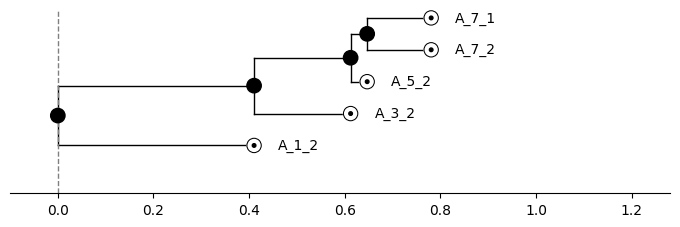

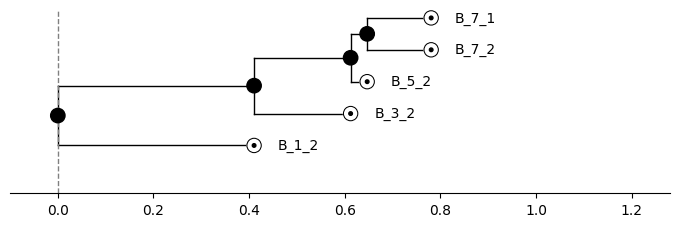

In [23]:
# 5. Run the simulation

coupling_prob = random.random()
print(f"\nCoupling probability p = {coupling_prob:.3f}\n")

family_A, family_B = simulate_coupled_families(
    species_tree, coupling_prob, max_leaves=5
)

print("\nFamily A tree:")
print(to_newick(family_A, reconc=True))
tv.visualize(family_A, save_as="family_A.pdf")

print("\nFamily B tree:")
print(to_newick(family_B, reconc=True))
tv.visualize(family_B, save_as="family_B.pdf")

A random coupling probability between 0 and 1 is drawn. One single call produces both trees.

In [24]:
# 6. Event summary

def count_events(tree):
    counts = {"S": 0, "D": 0}
    for node in tree.preorder():
        if hasattr(node, "event") and node.event in counts:
            counts[node.event] += 1
    return counts

print("\nEvent summary:")
print("Family A:", count_events(family_A))
print("Family B:", count_events(family_B))


Event summary:
Family A: {'S': 9, 'D': 0}
Family B: {'S': 9, 'D': 0}
